--- 원본 데이터 상위 5개 항목 ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
--------------------------------------------------


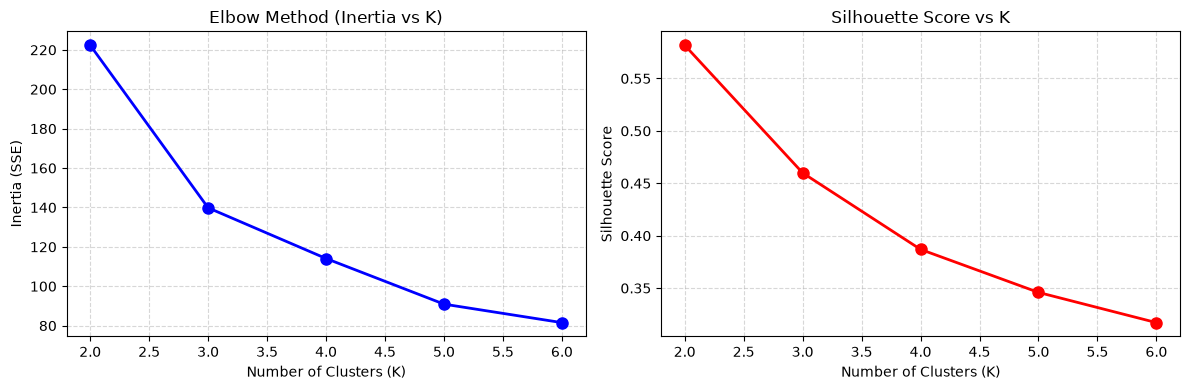

=== 최종 K-Means 평가 결과 (K=3) ===
1. Inertia (군집 내 SSE)         : 139.8205
2. 실루엣 계수 (Silhouette Score) : 0.4599 (1에 가까울수록 양호)
3. Calinski-Harabasz Index     : 241.9044 (높을수록 양호)
4. Davies-Bouldin Index        : 0.8336 (0에 가까울수록 양호)
--------------------------------------------------


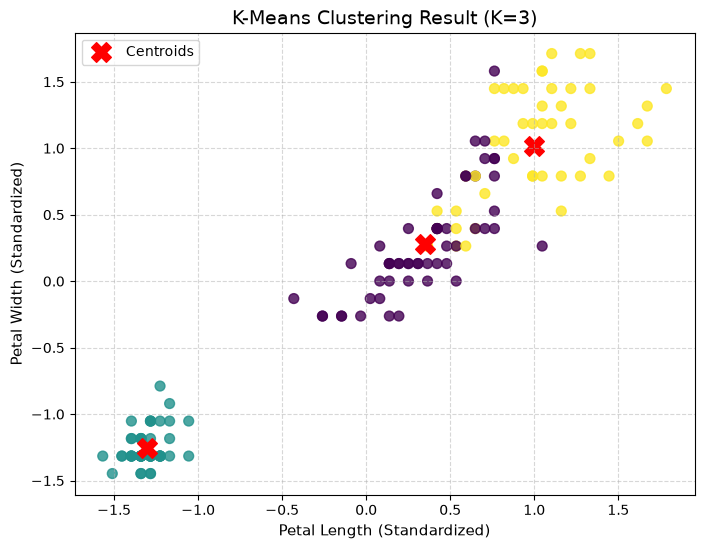

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

# ==================================================
# 1. 데이터 로드 및 확인
# ==================================================
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Pandas DataFrame으로 변환
df = pd.DataFrame(X, columns=feature_names)
print("--- 원본 데이터 상위 5개 항목 ---")
print(df.head())
print("-" * 50)

# ==================================================
# 2. 데이터 전처리 (StandardScaler)
# ==================================================
# 거리 기반 알고리즘 특성상 변수 간 스케일 차이가 크면 거리가 편향됩니다.
# 평균 0, 표준편차 1로 맞춰주는 표준화(Standardization) 작업 필수!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================================================
# 3. 최적의 K(군집 수) 탐색 (Elbow Method & Silhouette Score)
# ==================================================
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
  kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
  labels = kmeans.fit_predict(X_scaled)

  inertias.append(kmeans.inertia_)
  sil_scores.append(silhouette_score(X_scaled, labels))

# 최적 K 탐색 그래프 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow Method
axes[0].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Method (Inertia vs K)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Silhouette Score
axes[1].plot(K_range, sil_scores, "ro-", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ==================================================
# 4. 최종 K-Means 모델 생성 및 학습 (K=3 선택)
# ==================================================
best_k = 3
final_kmeans = KMeans(
    n_clusters=best_k, init="k-means++", n_init=10, random_state=42
)
final_labels = final_kmeans.fit_predict(X_scaled)
centroids = final_kmeans.cluster_centers_

# 결과를 DataFrame에 추가
df["Cluster"] = final_labels

# ==================================================
# 5. 모델 평가 (Evaluation Metrics)
# ==================================================
sil = silhouette_score(X_scaled, final_labels)
ch = calinski_harabasz_score(X_scaled, final_labels)
db = davies_bouldin_score(X_scaled, final_labels)

print(f"=== 최종 K-Means 평가 결과 (K={best_k}) ===")
print(f"1. Inertia (군집 내 SSE)         : {final_kmeans.inertia_:.4f}")
print(f"2. 실루엣 계수 (Silhouette Score) : {sil:.4f} (1에 가까울수록 양호)")
print(f"3. Calinski-Harabasz Index     : {ch:.4f} (높을수록 양호)")
print(f"4. Davies-Bouldin Index        : {db:.4f} (0에 가까울수록 양호)")
print("-" * 50)

# ==================================================
# 6. 군집화 결과 시각화 (2개 주요 특성 기준)
# ==================================================
plt.figure(figsize=(8, 6))

# 꽃잎 길이(Petal Length)와 꽃잎 너비(Petal Width) 특성을 기준으로 산점도 생성
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=final_labels,
    cmap="viridis",
    s=50,
    alpha=0.8,
)
plt.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)

plt.title(f"K-Means Clustering Result (K={best_k})", fontsize=14)
plt.xlabel("Petal Length (Standardized)", fontsize=11)
plt.ylabel("Petal Width (Standardized)", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

--- 원본 데이터 상위 5개 항목 ---
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
--------------------------------------------------


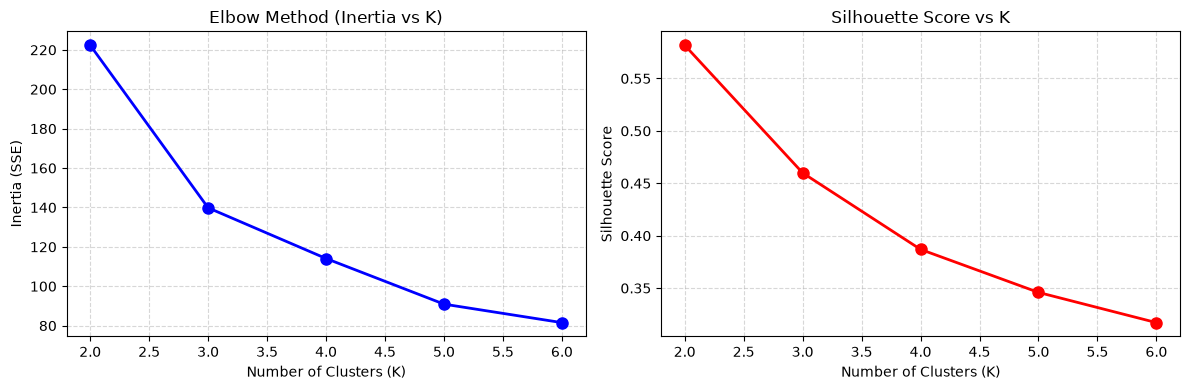

=== 최종 K-Means 평가 결과 (K=3) ===
1. Inertia (군집 내 SSE)         : 139.8205
2. 실루엣 계수 (Silhouette Score) : 0.4599 (1에 가까울수록 양호)
3. Calinski-Harabasz Index     : 241.9044 (높을수록 양호)
4. Davies-Bouldin Index        : 0.8336 (0에 가까울수록 양호)
--------------------------------------------------


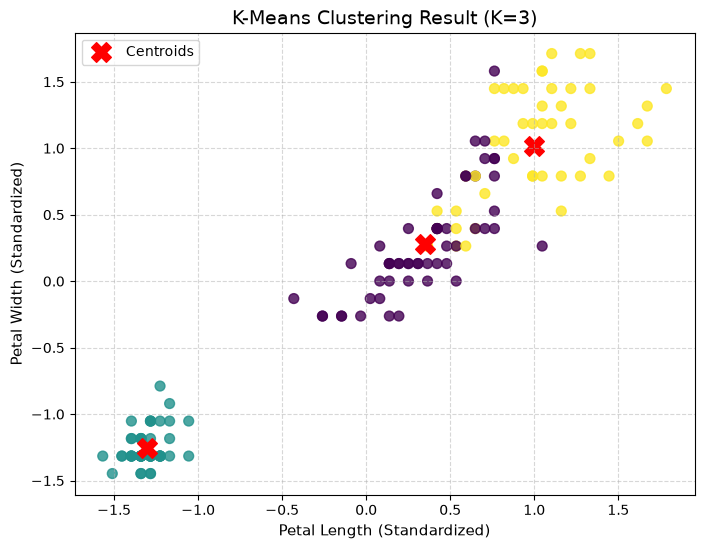

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

# ==================================================
# 1. 데이터 로드 및 확인
# ==================================================
iris = load_iris()
X = iris.data
feature_names = iris.feature_names

# Pandas DataFrame으로 변환
df = pd.DataFrame(X, columns=feature_names)
print("--- 원본 데이터 상위 5개 항목 ---")
print(df.head())
print("-" * 50)

# ==================================================
# 2. 데이터 전처리 (StandardScaler)
# ==================================================
# 거리 기반 알고리즘 특성상 변수 간 스케일 차이가 크면 거리가 편향됩니다.
# 평균 0, 표준편차 1로 맞춰주는 표준화(Standardization) 작업 필수!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==================================================
# 3. 최적의 K(군집 수) 탐색 (Elbow Method & Silhouette Score)
# ==================================================
inertias = []
sil_scores = []
K_range = range(2, 7)

for k in K_range:
  kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
  labels = kmeans.fit_predict(X_scaled)

  inertias.append(kmeans.inertia_)
  sil_scores.append(silhouette_score(X_scaled, labels))

# 최적 K 탐색 그래프 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow Method
axes[0].plot(K_range, inertias, "bo-", linewidth=2, markersize=8)
axes[0].set_title("Elbow Method (Inertia vs K)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (SSE)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# Silhouette Score
axes[1].plot(K_range, sil_scores, "ro-", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ==================================================
# 4. 최종 K-Means 모델 생성 및 학습 (K=3 선택)
# ==================================================
best_k = 3
final_kmeans = KMeans(
    n_clusters=best_k, init="k-means++", n_init=10, random_state=42
)
final_labels = final_kmeans.fit_predict(X_scaled)
centroids = final_kmeans.cluster_centers_

# 결과를 DataFrame에 추가
df["Cluster"] = final_labels

# ==================================================
# 5. 모델 평가 (Evaluation Metrics)
# ==================================================
sil = silhouette_score(X_scaled, final_labels)
ch = calinski_harabasz_score(X_scaled, final_labels)
db = davies_bouldin_score(X_scaled, final_labels)

print(f"=== 최종 K-Means 평가 결과 (K={best_k}) ===")
print(f"1. Inertia (군집 내 SSE)         : {final_kmeans.inertia_:.4f}")
print(f"2. 실루엣 계수 (Silhouette Score) : {sil:.4f} (1에 가까울수록 양호)")
print(f"3. Calinski-Harabasz Index     : {ch:.4f} (높을수록 양호)")
print(f"4. Davies-Bouldin Index        : {db:.4f} (0에 가까울수록 양호)")
print("-" * 50)

# ==================================================
# 6. 군집화 결과 시각화 (2개 주요 특성 기준)
# ==================================================
plt.figure(figsize=(8, 6))

# 꽃잎 길이(Petal Length)와 꽃잎 너비(Petal Width) 특성을 기준으로 산점도 생성
plt.scatter(
    X_scaled[:, 2],
    X_scaled[:, 3],
    c=final_labels,
    cmap="viridis",
    s=50,
    alpha=0.8,
)
plt.scatter(
    centroids[:, 2],
    centroids[:, 3],
    c="red",
    s=200,
    marker="X",
    label="Centroids",
)

plt.title(f"K-Means Clustering Result (K={best_k})", fontsize=14)
plt.xlabel("Petal Length (Standardized)", fontsize=11)
plt.ylabel("Petal Width (Standardized)", fontsize=11)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

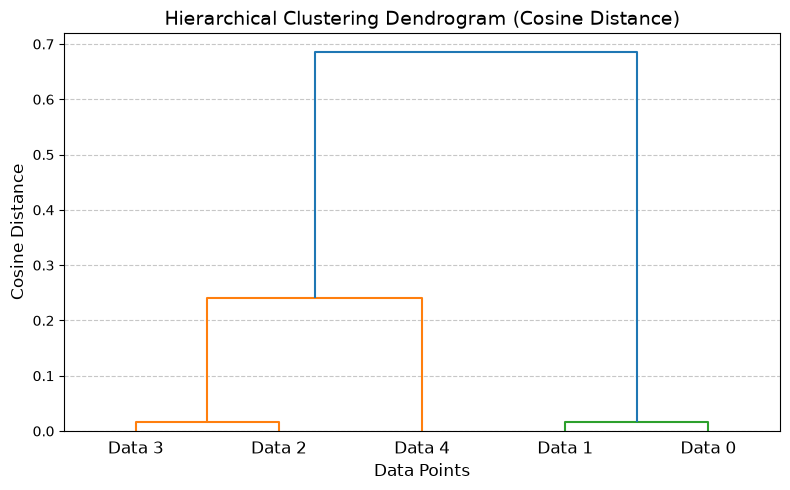

--- 군집화 결과 ---
Data 0 -> Cluster 1
Data 1 -> Cluster 1
Data 2 -> Cluster 2
Data 3 -> Cluster 2
Data 4 -> Cluster 2


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist

# 1. 샘플 데이터 생성 (5개의 문서 또는 아이템의 특징 벡터)
# 코사인 거리는 방향성이 중요하므로 스파스(Sparse)하거나 고차원 특성 벡터에 유용합니다.
data = np.array(
    [
        [1.0, 0.9, 0.0, 0.0],  # 데이터 0 (A그룹 유사)
        [0.8, 1.0, 0.1, 0.0],  # 데이터 1 (A그룹 유사)
        [0.1, 0.0, 0.9, 1.0],  # 데이터 2 (B그룹 유사)
        [0.0, 0.2, 0.8, 0.9],  # 데이터 3 (B그룹 유사)
        [0.5, 0.5, 0.5, 0.5],  # 데이터 4 (중간 특성)
    ]
)

labels = ["Data 0", "Data 1", "Data 2", "Data 3", "Data 4"]

# 2. 코사인 거리 행렬(Distance Matrix) 계산
# metric='cosine'을 지정하여 코사인 거리를 계산합니다.
# 코사인 거리 = 1 - 코사인 유사도
distance_matrix = pdist(data, metric="cosine")

# 3. 계층적 군집화 수행 (Linkage 계산)
# 와드(Ward)법은 유클리드 거리만 지원하므로,
# 코사인 거리 사용 시 'average', 'complete', 'single' 등의 연결법을 사용합니다.
Z = linkage(distance_matrix, method="average")

# 4. 덴드로그램 시각화
plt.figure(figsize=(8, 5))
dendrogram(Z, labels=labels, orientation="top", distance_sort="descending")

plt.title("Hierarchical Clustering Dendrogram (Cosine Distance)", fontsize=14)
plt.xlabel("Data Points", fontsize=12)
plt.ylabel("Cosine Distance", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# 5. 특정 거리 임계값(Threshold) 또는 군집 수 기준으로 클러스터 라벨 추출
# 예: 코사인 거리가 0.5 이하인 것끼리 묶기
max_d = 0.5
clusters = fcluster(Z, criterion="distance", t=max_d)

print("--- 군집화 결과 ---")
for label, cluster_id in zip(labels, clusters):
  print(f"{label} -> Cluster {cluster_id}")